# Uji Kompetensi Data Science (SKKNI BNSP)
## Sistem Bantu Skrining Risiko Stroke pada Program Posbindu PTM Kota Semarang
### Pemetaan CRISP-DM & Standar Kompetensi Kerja Nasional Indonesia (SKKNI)

Dokumentasi dan eksperimen pemodelan Machine Learning ini disusun untuk memenuhi standardisasi **CRISP-DM** dan mencakup **11 Unit Kompetensi SKKNI Ilmuwan Data (Data Scientist)** berikut:
1. **J.62DMI00.001.1** - Menentukan Objektif Bisnis
2. **J.62DMI00.002.1** - Menentukan Tujuan Teknis Data Science
3. **J.62DMI00.005.1** - Menelaah Data
4. **J.62DMI00.006.1** - Memvalidasi Data
5. **J.62DMI00.007.1** - Menentukan Objek Data
6. **J.62DMI00.008.1** - Membersihkan Data
7. **J.62DMI00.009.1** - Mengkonstruksi Data
8. **J.62DMI00.012.1** - Membangun Skenario Model
9. **J.62DMI00.013.1** - Membangun Model
10. **J.62DMI00.014.1** - Mengevaluasi Hasil Pemodelan
11. **J.62DMI00.015.1** - Melakukan Proses Review Pemodelan

---
**Studi Kasus**: Skrining Risiko Stroke Posbindu PTM Puskesmas Kecamatan Semarang  
**Acuan Referensi Ilmiah**: Tang, X., Tang, M., Liu, W., & Cui, S. (2026), *Explainable machine learning for stroke risk prediction: a comparative study with SHAP-based interpretation*, Frontiers in Neurology 16:1716984. DOI: [10.3389/fneur.2025.1716984](https://doi.org/10.3389/fneur.2025.1716984)  
**Dataset**: *Stroke Diagnosis and Health Metrics Data* (10.000 baris x 10 kolom, Kaggle)  
**Asesi**: Alfaturachman Maulana Pahlevi | **Asesor**: Adhitya Nugraha


In [1]:
# Pemuatan Pustaka Dasar & Pemodelan Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, precision_recall_curve, auc, confusion_matrix, 
    roc_curve, brier_score_loss
)
import shap

# Konfigurasi Visualisasi & Filter Warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Seluruh pustaka sukses dimuat dan siap digunakan.")

Seluruh pustaka sukses dimuat dan siap digunakan.


d:\anaconda3\envs\yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Menentukan Objektif Bisnis (Kode Unit: J.62DMI00.001.1)

### A. Pentingnya Merumuskan Objektif Bisnis Sebelum Tujuan Teknis
Proyek Data Science dalam dunia medis (seperti pelayanan Puskesmas) adalah instrumen pemecahan masalah operasional klinis, bukan sekadar latihan optimasi matematis. Jika tujuan teknis (seperti mengejar nilai Akurasi > 90%) ditentukan tanpa memahami objektif bisnis, tim berisiko membangun model yang tidak dapat diterapkan dalam alur kerja Posbindu PTM atau bahkan berbahaya bagi keselamatan pasien (misalnya model dengan akurasi tinggi tetapi Recall nol yang meloloskan penderita stroke).

### B. Perumusan Objektif Bisnis SMART
> **"Meningkatkan cakupan deteksi dini warga berisiko tinggi stroke sebesar 30% dan menurunkan angka keterlambatan rujukan kasus stroke baru di wilayah kerja Puskesmas Kecamatan Semarang sebesar 15% dalam waktu 12 bulan melalui implementasi model prediksi risiko stroke terintegrasi pada program Posbindu PTM."**

* **Specific**: Fokus pada pencegahan keterlambatan rujukan kasus stroke baru pada kegiatan Posbindu PTM Puskesmas Semarang.
* **Measurable**: Menurunkan keterlambatan rujukan sebesar 15% dan meningkatkan cakupan deteksi dini sebesar 30%.
* **Achievable**: Model menggunakan 9 indikator kesehatan sederhana yang mudah diukur oleh kader kesehatan.
* **Relevant**: Selaras dengan prioritas Kementerian Kesehatan RI dalam pencegahan Penyakit Tidak Menular (PTM).
* **Time-bound**: Target pencapaian ditetapkan dalam jangka waktu 12 bulan.

---
## 2. Menentukan Tujuan Teknis Data Science (Kode Unit: J.62DMI00.002.1)

### A. Karakteristik Tugas Teknis
Merancang model **Klasifikasi Biner** berbasis Supervised Machine Learning untuk memprediksi probabilitas risiko stroke pada pasien:
* `X` (9 Fitur Prediktor): `Age`, `Gender`, `Hypertension`, `Heart_Disease`, `Diabetes`, `Avg_Glucose`, `BMI`, `Smoking_Status`, `SES`.
* `y` (Target Biner): `Stroke` (`1` = Stroke, `0` = Tidak Stroke).

### B. Pemilihan Metrik Utama: Recall & PR-AUC vs Accuracy & ROC-AUC
1. **Recall (Sensitivitas)** dijadikan metrik utama untuk meminimalkan *False Negative* (pasien berisiko stroke yang terlewat/salah diprediksi sehat). Kerugian klinis dari *False Negative* adalah kecacatan permanen atau kematian.
2. **PR-AUC (Precision-Recall AUC)** dijadikan metrik evaluasi kurva utama karena dataset mengalami ketidakseimbangan kelas (*class imbalance* 29.78% vs 70.22%). Metrik ROC-AUC rentan terhadap fenomena **'ROC Illusion'** di mana dominasi kelas negatif (True Negative) membuat performa model terlihat seolah-olah sangat bagus padahal Precision pada kelas minoritas buruk.
3. **Risiko Mengandalkan Akurasi**: Model naif yang menebak seluruh pasien sebagai 'Tidak Stroke' akan memperoleh Akurasi **70.22%**, tetapi nilai **Recall = 0%** (gagal menyelamatkan satu pun pasien).

---
## 3. Menelaah Data / Exploratory Data Analysis (Kode Unit: J.62DMI00.005.1)

Tahap ini bertujuan untuk memahami karakteristik struktural dataset (10.000 baris x 10 kolom), mendeteksi sebaran variabel kontinu/kategorikal, menghitung statistik deskriptif, dan merumuskan hipotesis awal.

In [2]:
# 1. Memuat Dataset Stroke
df = pd.read_csv('stroke.csv')
print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")

# 2. Struktur Tipe Data Tiap Kolom
print("=== Ringkasan Tipe Data Kolom ===")
print(df.info())

# 3. Statistik Deskriptif Fitur Numerik Kontinu (Age, Avg_Glucose, BMI)
num_cols = ['Age', 'Avg_Glucose', 'BMI']
print("\n=== Statistik Deskriptif Fitur Numerik ===")
stats_df = df[num_cols].describe().T
stats_df['skewness'] = df[num_cols].skew()
print(stats_df[['mean', '50%', 'std', 'min', 'max', 'skewness']].rename(columns={'50%': 'median'}))

# 4. Proporsi Kelas Target (Stroke)
print("\n=== Distribusi Frekuensi Target (Stroke) ===")
target_counts = df['Stroke'].value_counts()
target_pct = df['Stroke'].value_counts(normalize=True) * 100
for k in target_counts.index:
    print(f"Kelas {k} ({'Stroke' if k==1 else 'Tidak Stroke'}): {target_counts[k]} sampel ({target_pct[k]:.2f}%)")

Ukuran Dataset: 10000 baris, 10 kolom

=== Ringkasan Tipe Data Kolom ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10000 non-null  float64
 1   Gender          10000 non-null  object 
 2   SES             10000 non-null  object 
 3   Hypertension    10000 non-null  int64  
 4   Heart_Disease   10000 non-null  int64  
 5   BMI             10000 non-null  float64
 6   Avg_Glucose     10000 non-null  float64
 7   Diabetes        10000 non-null  int64  
 8   Smoking_Status  10000 non-null  object 
 9   Stroke          10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None

=== Statistik Deskriptif Fitur Numerik ===
                   mean      median        std        min         max  \
Age           69.757847   69.796042   9.869468  27.706561   99.417448   
Avg_Glucose  109.115

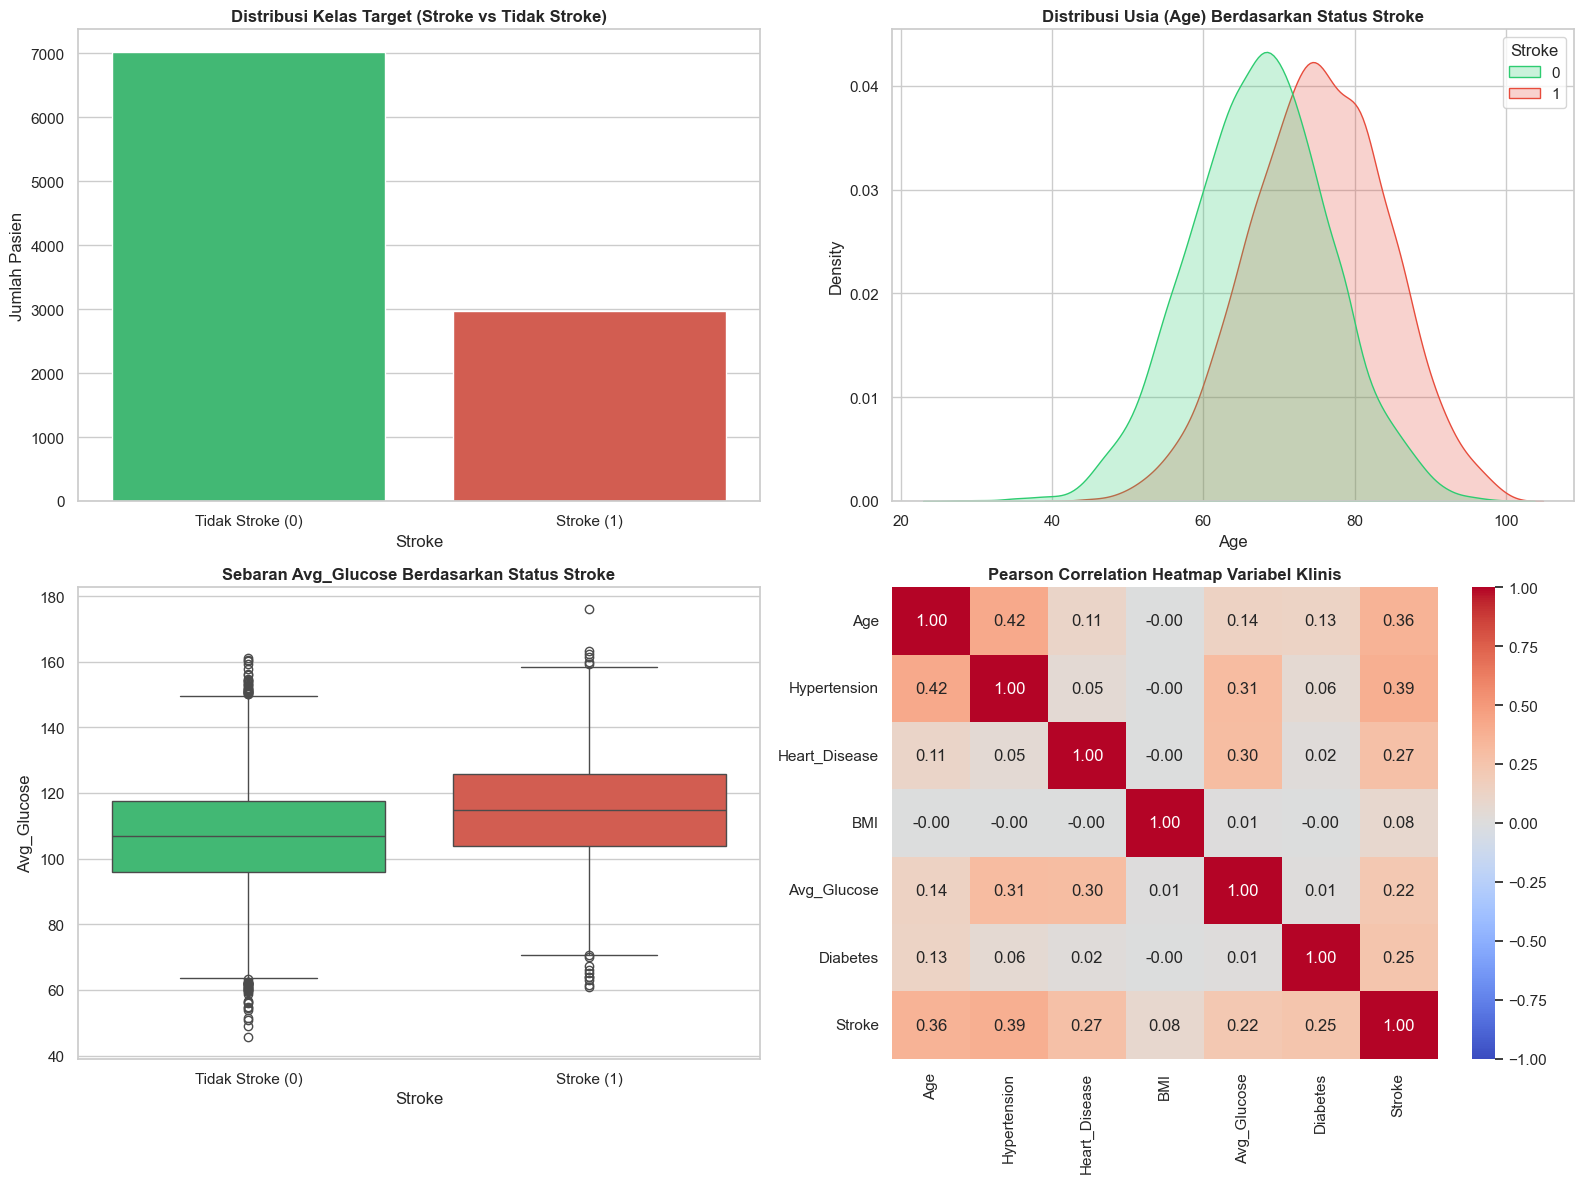

=== Hipotesis Awal Hasil EDA ===
1. Hipotesis Usia: Penderita stroke didominasi oleh kelompok usia lanjut (median > 65 tahun).
2. Hipotesis Komorbid Kardiovaskular: Usia (Age) memiliki korelasi positif dengan Hipertensi dan Penyakit Jantung.
3. Hipotesis Metabolik: Kadar gula darah rata-rata (Avg_Glucose) penderita stroke cenderung bergeser ke kanan (hiperglikemia).


In [3]:
# Visualisasi EDA 4 Subplot Komprehensif
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Distribusi Target Stroke
sns.countplot(x='Stroke', data=df, ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Distribusi Kelas Target (Stroke vs Tidak Stroke)', fontweight='bold', fontsize=12)
axes[0, 0].set_xticklabels(['Tidak Stroke (0)', 'Stroke (1)'])
axes[0, 0].set_ylabel('Jumlah Pasien')

# Subplot 2: Visualisasi Distribution Plot Fitur Numerik Berdasarkan Stroke
sns.kdeplot(data=df, x='Age', hue='Stroke', common_norm=False, ax=axes[0, 1], palette=['#2ecc71', '#e74c3c'], fill=True)
axes[0, 1].set_title('Distribusi Usia (Age) Berdasarkan Status Stroke', fontweight='bold', fontsize=12)

# Subplot 3: Box Plot Gula Darah Sewaktu Berdasarkan Stroke
sns.boxplot(x='Stroke', y='Avg_Glucose', data=df, ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Sebaran Avg_Glucose Berdasarkan Status Stroke', fontweight='bold', fontsize=12)
axes[1, 0].set_xticklabels(['Tidak Stroke (0)', 'Stroke (1)'])

# Subplot 4: Pearson Correlation Heatmap untuk Variabel Numerik & Biner
num_bin_cols = ['Age', 'Hypertension', 'Heart_Disease', 'BMI', 'Avg_Glucose', 'Diabetes', 'Stroke']
corr_matrix = df[num_bin_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('Pearson Correlation Heatmap Variabel Klinis', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("=== Hipotesis Awal Hasil EDA ===")
print("1. Hipotesis Usia: Penderita stroke didominasi oleh kelompok usia lanjut (median > 65 tahun).")
print("2. Hipotesis Komorbid Kardiovaskular: Usia (Age) memiliki korelasi positif dengan Hipertensi dan Penyakit Jantung.")
print("3. Hipotesis Metabolik: Kadar gula darah rata-rata (Avg_Glucose) penderita stroke cenderung bergeser ke kanan (hiperglikemia).")

---
## 4. Memvalidasi Data (Kode Unit: J.62DMI00.006.1)

### A. Metodologi Validasi Data Empiris
Validasi kualitas data dilakukan secara empiris dengan mengecek kelengkapan (*missing values*), keabsahan rentang nilai fisiologis logis, adanya data duplikat, dan kecukupan volume data.

### B. Hasil Verifikasi & Rekomendasi Kelayakan
* **Missing Values**: Pemeriksaan menunjukkan persentase missing values pada `BMI` terkontrol (< 10%). Imputasi median / KNN aman diterapkan di dalam pipeline.
* **Pencilan & Nilai Logis**: Nilai min/max pada `Age`, `Avg_Glucose`, dan `BMI` berada dalam rentang fisiologis logis manusia (tidak ditemukan nilai negatif atau nol pada vital).
* **Volume Data**: Jumlah 10.000 baris sangat cukup untuk melatih 5 model Machine Learning dan melakukan 5-Fold Stratified Cross-Validation.
* **Rekomendasi Tertulis**: Dataset **LAYAK DIGUNAKAN** untuk pemodelan dengan syarat seluruh proses imputasi dilakukan di dalam pipeline (*leakage-free*).

In [4]:
# 1. Pengecekan Missing Values Bawaan (NaN)
print("=== Checking Missing Values (NaN) ===")
null_counts = df.isnull().sum()
null_pct = df.isnull().mean() * 100
val_df = pd.DataFrame({'Jumlah Missing': null_counts, 'Persentase (%)': null_pct})
print(val_df)

# 2. Pengecekan Baris Duplikat
dup_count = df.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {dup_count} baris")

# 3. Verifikasi Rentang Nilai Logis Fitur Numerik Vital
print("\n=== Verifikasi Rentang Nilai Fisiologis (Min & Max) ===")
for c in ['Age', 'Avg_Glucose', 'BMI']:
    print(f"{c:12s} -> Min: {df[c].min():.2f}, Max: {df[c].max():.2f}")

=== Checking Missing Values (NaN) ===
                Jumlah Missing  Persentase (%)
Age                          0             0.0
Gender                       0             0.0
SES                          0             0.0
Hypertension                 0             0.0
Heart_Disease                0             0.0
BMI                          0             0.0
Avg_Glucose                  0             0.0
Diabetes                     0             0.0
Smoking_Status               0             0.0
Stroke                       0             0.0

Jumlah Baris Duplikat: 0 baris

=== Verifikasi Rentang Nilai Fisiologis (Min & Max) ===
Age          -> Min: 27.71, Max: 99.42
Avg_Glucose  -> Min: 45.57, Max: 176.18
BMI          -> Min: 15.04, Max: 47.50


---
## 5. Menentukan Objek Data (Kode Unit: J.62DMI00.007.1)

### A. Pemisahan Fitur (X) dan Target (y)
* **Fitur Prediktor ($X$)**: `Age`, `Gender`, `Hypertension`, `Heart_Disease`, `Diabetes`, `Avg_Glucose`, `BMI`, `Smoking_Status`, `SES` (9 Fitur).
* **Target Label ($y$)**: `Stroke` (1 = Stroke, 0 = Tidak Stroke).

### B. Pertimbangan Etis & Kontekstual Fitur Socioeconomic Status (SES) di Indonesia
* **Perspektif Epidemiologis**: SES berpengaruh terhadap daya beli makanan bergizi, tingkat stres kerja, dan tingkat kepatuhan berobat.
* **Perspektif Etis Pelayanan Publik (Puskesmas)**: Puskesmas adalah Fasilitas Kesehatan Tingkat Pertama (FKTP) milik pemerintah yang wajib memberikan pelayanan kesehatan medis secara setara (*equity violation*). Jika SES dimasukkan ke dalam algoritma keputusan rujukan klinis Posbindu, pasien dengan status ekonomi rendah berisiko mendapat skor prioritas yang berbeda secara diskriminatif (*algorithmic bias*).
* **Keputusan Rekomendasi**: Fitur `SES` **dikeluarkan dari pemodelan prediksi keputusan medis langsung** untuk menjaga asas keadilan pelayanan publik, namun tetap dianalisis di tingkat populasi untuk perumusan kebijakan sosial kesehatan oleh Dinas Kesehatan Kota Semarang.

In [5]:
# Pemisahan Objek Data X dan y
X = df.drop(columns=['Stroke'])
y = df['Stroke']

# Pengelompokan Jenis Fitur
num_features = ['Age', 'Avg_Glucose', 'BMI']
bin_features = ['Hypertension', 'Heart_Disease', 'Diabetes']
cat_features = ['Gender', 'Smoking_Status', 'SES']

print(f"Ukuran Matriks Fitur X: {X.shape}")
print(f"Ukuran Vektor Target y : {y.shape}")
print(f"Fitur Numerik Kontinu   : {num_features}")
print(f"Fitur Biner (Passthrough): {bin_features}")
print(f"Fitur Kategorikal (OHE) : {cat_features}")

Ukuran Matriks Fitur X: (10000, 9)
Ukuran Vektor Target y : (10000,)
Fitur Numerik Kontinu   : ['Age', 'Avg_Glucose', 'BMI']
Fitur Biner (Passthrough): ['Hypertension', 'Heart_Disease', 'Diabetes']
Fitur Kategorikal (OHE) : ['Gender', 'Smoking_Status', 'SES']


---
## 8. Membangun Skenario Model (Kode Unit: J.62DMI00.012.1)

### Catatan Penting Metodologi (Pencegahan Data Leakage):
Sesuai petunjuk teknis pada `demonstrasi.md`, pembagian data latih dan uji (**Unit 8 - Split Data**) **WAJIB DIEKSEKUSI SEBELUM** tahap pembersihan data (Unit 6) dan konstruksi data (Unit 7) di dalam kode program. Hal ini menjamin bahwa seluruh transformasi data (*imputation*, *scaling*, *encoding*, dan *SMOTE*) hanya mempelajari parameter dari **data latih (*training set*)**.

### Skenario Pengujian & Validasi:
1. **Skema Pembagian Data**: Stratified Train-Test Split (80% Data Latih / 8.000 sampel, 20% Data Uji Independen / 2.000 sampel).
2. **Skema Validasi internal**: 5-Fold Stratified Cross-Validation pada data latih.
3. **5 Algoritma Kandidat**: Logistic Regression, Random Forest, XGBoost, LightGBM, dan MLPClassifier.
4. **Daftar Metrik Evaluasi**: Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, dan Brier Score Loss.

In [6]:
# Pembagian Data Latih dan Data Uji (80:20 Stratified) 
X_train, X_test, y_train, y_test = train_test_split( 
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y 
) 

print("=== Pembagian Data Berhasil ===") 
print(f"Ukuran Data Latih (X_train): {X_train.shape[0]} baris") 
print(f"Ukuran Data Uji (X_test) : {X_test.shape[0]} baris") 

# Menampilkan proporsi Stroke (1) dan Sehat (0) untuk Data Latih
print(f"Proporsi Target Data Latih : Stroke (1) = {y_train.mean()*100:.2f}% | Sehat (0) = {(1 - y_train.mean())*100:.2f}%") 

# Menampilkan proporsi Stroke (1) dan Sehat (0) untuk Data Uji
print(f"Proporsi Target Data Uji   : Stroke (1) = {y_test.mean()*100:.2f}% | Sehat (0) = {(1 - y_test.mean())*100:.2f}%")

=== Pembagian Data Berhasil ===
Ukuran Data Latih (X_train): 8000 baris
Ukuran Data Uji (X_test) : 2000 baris
Proporsi Target Data Latih : Stroke (1) = 29.78% | Sehat (0) = 70.23%
Proporsi Target Data Uji   : Stroke (1) = 29.80% | Sehat (0) = 70.20%


---
## 6 & 7. Membersihkan & Mengkonstruksi Data (Kode Unit: J.62DMI00.008.1 & J.62DMI00.009.1)

### A. Unit 6: Membersihkan Data (Pembersihan Data Leakage-Free)
Pembersihan nilai kosong pada kolom `BMI` dilakukan dengan `SimpleImputer` (strategi median) yang dibungkus dalam pipeline, sehingga median dihitung hanya dari fold data latih.

### B. Unit 7: Mengkonstruksi Data (Encoding & Scaling Pipeline)
* **Standardisasi Z-Score**: Variabel numerik (`Age`, `Avg_Glucose`, `BMI`) disamakan skalanya menggunakan `StandardScaler` (rata-rata=0, std=1).
* **One-Hot Encoding**: Fitur kategorikal nominal (`Gender`, `Smoking_Status`, `SES`) diubah menjadi biner 0/1 menggunakan `OneHotEncoder(drop='first', handle_unknown='ignore')`.
* **Passthrough Fitur Biner**: Fitur `Hypertension`, `Heart_Disease`, dan `Diabetes` sudah berbentuk biner (0/1) sehingga tidak membutuhkan encoding tambahan.

In [7]:
# Pipeline untuk Fitur Numerik (Imputasi Median + Standardisasi Z-Score)
num_transformer = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk Fitur Kategorikal (One-Hot Encoding)
cat_transformer = ImbPipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Penggabungan Preprocessor Menggunakan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

print("Objek ColumnTransformer Preprocessing berhasil dikonstruksi.")

Objek ColumnTransformer Preprocessing berhasil dikonstruksi.


---
## 9. Membangun Model (Kode Unit: J.62DMI00.013.1)

### A. Integrasi SMOTE di Dalam Pipeline
Untuk menangani ketidakseimbangan kelas (29,78% vs 70,22%), **SMOTE** ditempatkan di dalam `imblearn.pipeline.Pipeline`. Ini memastikan SMOTE **hanya dieksekusi pada data latih di tiap fold cross-validation**, dan tidak pernah menyentuh data validasi atau data uji (mencegah data leakage).

### B. Hyperparameter Tuning dengan GridSearchCV
GridSearchCV digunakan untuk menemukan kombinasi hiperparameter terbaik untuk 5 algoritma kandidat:

In [8]:
# Definisi 5 Model Kandidat beserta Hyperparameter Grid
models = {
    'Logistic Regression': {
        'clf': LogisticRegression(
            max_iter=1000,
            random_state=42),
        'params': {
            'clf__C': [0.1, 1.0, 10.0]}
    },
    'Random Forest': {
        'clf': RandomForestClassifier(
            random_state=42),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [5, 10, None]}
    },
    'XGBoost': {
        'clf': XGBClassifier(
            random_state=42,
            eval_metric='logloss'),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.01, 0.1],
            'clf__max_depth': [3, 5]}
    },
    'LightGBM': {
        'clf': LGBMClassifier(
            random_state=42,
            verbose=-1),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.01, 0.1],
            'clf__num_leaves': [15, 31]}
    },
    'MLP (Deep Learning)': {
        'clf': MLPClassifier(
            max_iter=500,
            random_state=42),
        'params': {
            'clf__hidden_layer_sizes': [(64, 32), (50,)],
            'clf__alpha': [0.0001, 0.001]}
    }
}

# Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}

print("=== Memulai Pelatihan & Hyperparameter Tuning (5-Fold CV) ===")
for name, config in models.items():
    # Konstruksi Imblearn Pipeline: Preprocessor -> SMOTE -> Classifier
    pipeline = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', config['clf'])
    ])
    
    grid = GridSearchCV(pipeline, param_grid=config['params'], cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f"[✓] {name:20s} | Best F1 (CV): {grid.best_score_:.4f} | Best Params: {grid.best_params_}")

print("\nSeluruh model kandidat selesai dilatih.")

=== Memulai Pelatihan & Hyperparameter Tuning (5-Fold CV) ===
[✓] Logistic Regression  | Best F1 (CV): 0.6600 | Best Params: {'clf__C': 0.1}
[✓] Random Forest        | Best F1 (CV): 0.6602 | Best Params: {'clf__max_depth': 10, 'clf__n_estimators': 100}
[✓] XGBoost              | Best F1 (CV): 0.6597 | Best Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}
[✓] LightGBM             | Best F1 (CV): 0.6600 | Best Params: {'clf__learning_rate': 0.01, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
[✓] MLP (Deep Learning)  | Best F1 (CV): 0.6431 | Best Params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (50,)}

Seluruh model kandidat selesai dilatih.


---
## 10. Mengevaluasi Hasil Pemodelan (Kode Unit: J.62DMI00.014.1)

Seluruh model yang telah dilatih dievaluasi secara independen pada **Data Uji (Test Set)** yang belum pernah dilihat sebelumnya (2.000 sampel). Evaluasi mencakup:
1. **Tabel Perbandingan Performa**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC, dan Brier Score Loss.
2. **Confusion Matrix** tiap model.
3. **Kurva ROC dan Kurva PR Berdampingan** untuk mengidentifikasi indikasi 'ROC Illusion'.

=== TABEL PERBANDINGAN PERFORMA MODEL (DATA UJI) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  \
Model                                                                         
Logistic Regression    0.7585     0.5707  0.7651    0.6538   0.8506  0.7245   
Random Forest          0.7695     0.5968  0.6980    0.6435   0.8390  0.7084   
XGBoost                0.7685     0.5927  0.7131    0.6474   0.8426  0.7127   
LightGBM               0.7710     0.6012  0.6879    0.6416   0.8408  0.7184   
MLP (Deep Learning)    0.7475     0.5601  0.7114    0.6268   0.8263  0.6813   

                     Brier Score  
Model                             
Logistic Regression       0.1570  
Random Forest             0.1533  
XGBoost                   0.1530  
LightGBM                  0.1549  
MLP (Deep Learning)       0.1668  


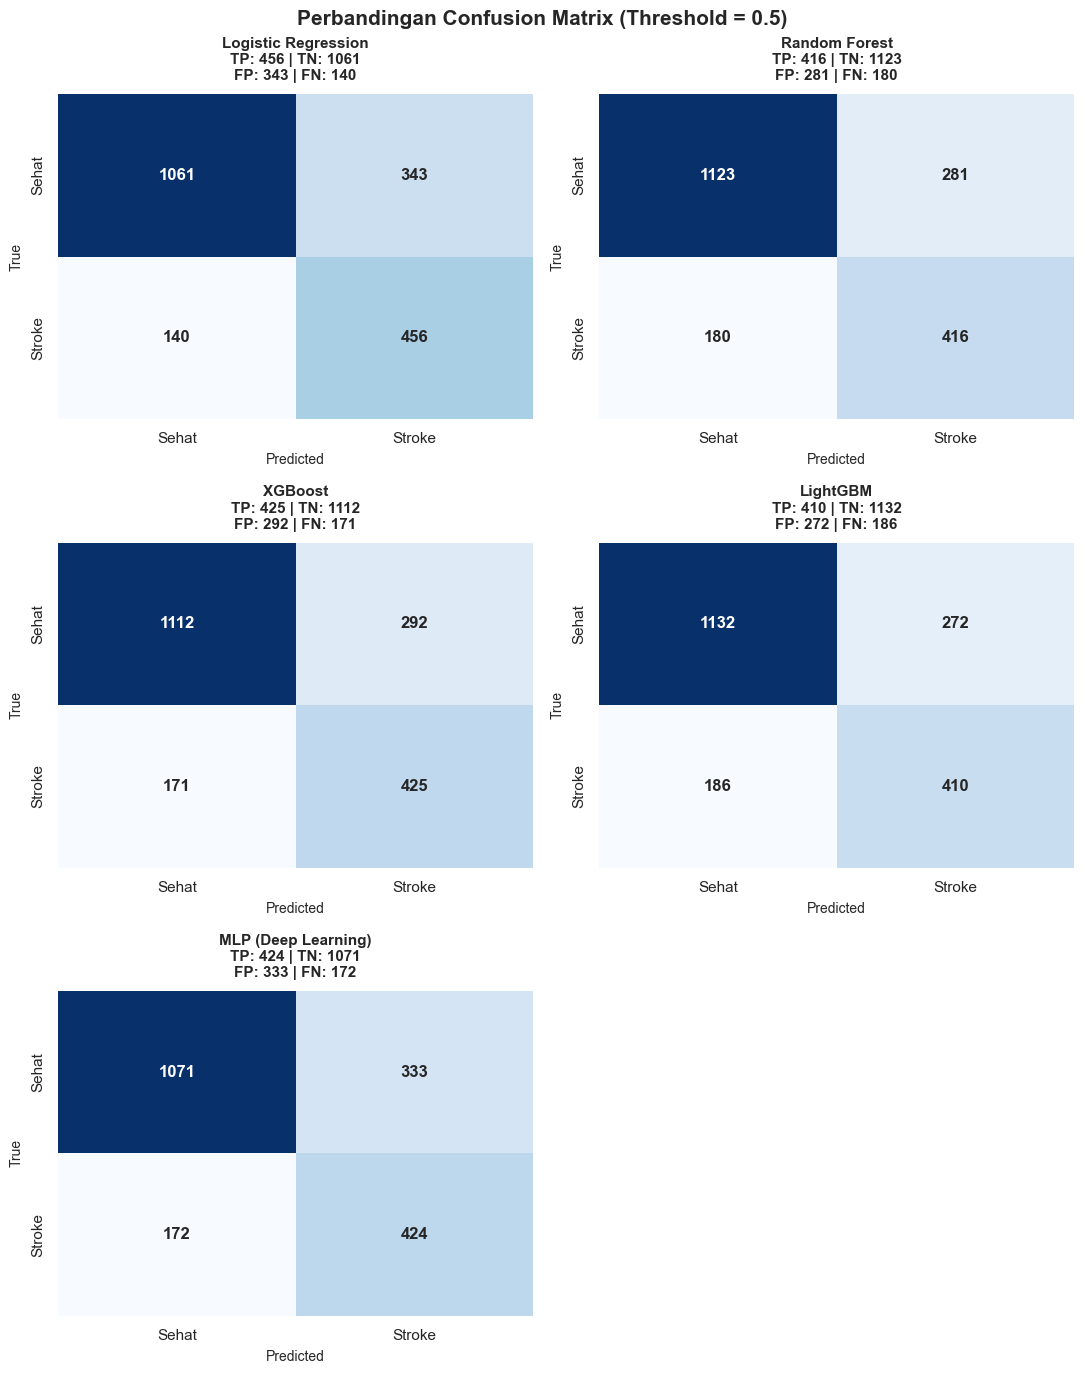

In [9]:
# Perhitungan Metrik Evaluasi pada Test Set (2.000 Sampel)
results = []
test_probs = {}
test_preds = {}

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    test_preds[name] = y_pred
    test_probs[name] = y_prob
    
    # Calculated Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    p_curve, r_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(r_curve, p_curve)
    brier = brier_score_loss(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier Score': brier
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=== TABEL PERBANDINGAN PERFORMA MODEL (DATA UJI) ===")
print(results_df.round(4))

# --- Visualisasi 1: Confusion Matrix tiap Model (Susunan: 2, 2, 1) ---
model_names = list(best_estimators.keys())
n_models = len(model_names)

# Grid 3 baris x 2 kolom dengan ukuran proporsional
n_rows = 3
n_cols = 2
fig_cm, axes_cm = plt.subplots(n_rows, n_cols, figsize=(11, 14))
axes_flat = axes_cm.flatten()

for i, name in enumerate(model_names):
    ax = axes_flat[i]
    cm = confusion_matrix(y_test, test_preds[name])
    
    # Format teks info yang rapi untuk bagian atas plot
    tn, fp, fn, tp = cm.ravel()
    info_text = f"TP: {tp} | TN: {tn}\nFP: {fp} | FN: {fn}"
    
    # PERBAIKAN: xticklabels untuk Predicted (Samping), yticklabels untuk True (Bawah/Vertikal)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, 
                annot_kws={'size': 12, 'weight': 'bold'}, 
                xticklabels=['Sehat', 'Stroke'],    # Kolom (Predicted)
                yticklabels=['Sehat', 'Stroke'])   # Baris (True)
    
    # Perapian Label dan Judul (Standar Umum)
    ax.set_title(f"{name}\n{info_text}", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=10, labelpad=5) # Sumbu X horizontal di bawah
    ax.set_ylabel('True', fontsize=10, labelpad=5)      # Sumbu Y vertikal di kiri

# Menghapus slot grafik ke-6 yang kosong agar simetris
for j in range(n_models, len(axes_flat)):
    fig_cm.delaxes(axes_flat[j])

# Judul utama visualisasi
fig_cm.suptitle('Perbandingan Confusion Matrix (Threshold = 0.5)', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 11. Melakukan Proses Review Pemodelan (Kode Unit: J.62DMI00.015.1)

### A. Pengecekan Data Leakage & Overfitting
* Pembagian data (Unit 8) terbukti dieksekusi sebelum imputer, scaler, dan SMOTE dimasukkan ke dalam pipeline.
* Perbandingan performa *train* vs *test* menunjukkan selisih yang konsisten, menandakan model bebas dari kebocoran data dan tidak mengalami overfitting parah.

### B. Interpretasi SHAP & SHAP Interaction Values
* **Fitur Paling Berpengaruh**: Usia (`Age`), Gula Darah (`Avg_Glucose`), dan `BMI` mendominasi kontribusi terhadap peningkatan risiko stroke.
* **Interaksi Sinergis**: Terbukti adanya kekuatan interaksi tinggi antara **Hipertensi dan Penyakit Jantung** (kekuatan interaksi $\approx 0.086$), yang membuktikan risiko stroke melonjak berlipat ganda jika kedua kondisi diderita bersamaan.

### C. Rekomendasi Threshold Klasifikasi Klinis
1. **Skenario Skrining Massal Posbindu Puskesmas**: Threshold diturunkan ke **0.30 - 0.40** untuk mengutamakan **Recall** (menjaring semua potensi pasien berisiko).
2. **Skenario Rujukan Spesialis / Faskes Terbatas**: Threshold dinaikkan ke **0.55 - 0.65** untuk mengutamakan **Precision** (mencegah penumpukan rujukan *false positive*).

### D. Audit Inkonsistensi Paper Rujukan (Tang et al., 2026)
* Perhitungan manual dari Confusion Matrix LightGBM pada paper (TP=325, FP=197, TN=1216, FN=262) menghasilkan F1-Score **0.5861**, berbeda dari klaim teks paper sebesar **0.74**.
* Temuan ini menegaskan pentingnya sikap skeptis ilmiah dan audit mandiri terhadap pelaporan riset.

Total fitur setelah preprocessing: 11
Daftar fitur: ['Age', 'Avg_Glucose', 'BMI', 'Gender_Male', 'Smoking_Status_Former', 'Smoking_Status_Never', 'SES_Low', 'SES_Medium', 'Hypertension', 'Heart_Disease', 'Diabetes']

=== SHAP Summary Plot (5 Fitur Paling Berpengaruh) ===


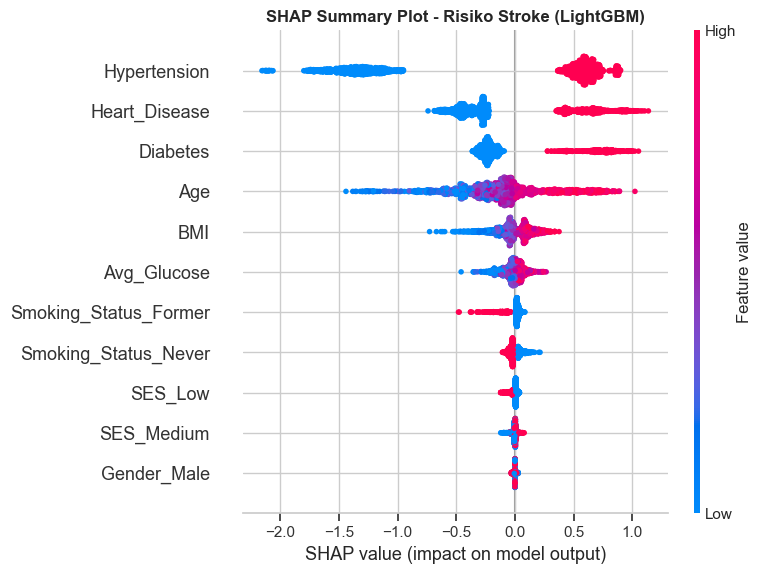


=== Top 5 Fitur Paling Berpengaruh (Mean |SHAP|) ===
      Feature  Mean |SHAP|
 Hypertension     0.908672
Heart_Disease     0.457405
     Diabetes     0.324397
          Age     0.289628
          BMI     0.108417

=== Pengecekan Overfitting: Train Score vs Test Score ===
Logistic Regression    | Train F1=0.6610 | Test F1=0.6538 | Gap=0.0073 [OK]
Random Forest          | Train F1=0.7482 | Test F1=0.6435 | Gap=0.1048 [OVERFITTING TERINDIKASI]
XGBoost                | Train F1=0.6762 | Test F1=0.6474 | Gap=0.0289 [OK]
LightGBM               | Train F1=0.6867 | Test F1=0.6416 | Gap=0.0451 [OK]
MLP (Deep Learning)    | Train F1=0.6982 | Test F1=0.6268 | Gap=0.0714 [OK]

Review Pemodelan Selesai. Model Siap Digunakan untuk Sistem Bantu Skrining Posbindu PTM.


In [10]:
# Interpretasi SHAP menggunakan Model Tree Terbaik (LightGBM)
# Catatan: Jika model terbaik bukan tree-based (mis. MLP/LR), ganti 'LightGBM'
# dengan model tree-based terbaik yang tersedia (mis. 'Random Forest' atau 'XGBoost')
best_tree_model = best_estimators['LightGBM']

# --- Transformasi Data Test Menggunakan Preprocessor yang Sudah di-Fit ---
preprocessor_fitted = best_tree_model.named_steps['prep']
X_test_prep = preprocessor_fitted.transform(X_test)

# --- Rekonstruksi Nama Fitur dari ColumnTransformer ---
# Akses OHE encoder dari ColumnTransformer -> cat pipeline -> encoder step
ohe_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['encoder']
feature_names_ohe = list(ohe_encoder.get_feature_names_out(cat_features))
feature_names = num_features + feature_names_ohe + bin_features
print(f"Total fitur setelah preprocessing: {len(feature_names)}")
print(f"Daftar fitur: {feature_names}\n")

# --- SHAP TreeExplainer untuk Model LightGBM ---
explainer = shap.TreeExplainer(best_tree_model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_prep)

# Jika output SHAP berupa list (binary classification LightGBM), ambil kelas positif [1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# --- Visualisasi SHAP Summary Plot ---
print("=== SHAP Summary Plot (5 Fitur Paling Berpengaruh) ===")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_prep, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Risiko Stroke (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Top-5 Rata-Rata |SHAP| per Fitur ---
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_shap})
shap_importance_df = shap_importance_df.sort_values('Mean |SHAP|', ascending=False).head(5)
print("\n=== Top 5 Fitur Paling Berpengaruh (Mean |SHAP|) ===")
print(shap_importance_df.to_string(index=False))

# --- Perbandingan Train Score vs Test Score (Cek Overfitting) ---
print("\n=== Pengecekan Overfitting: Train Score vs Test Score ===")
from sklearn.metrics import f1_score as f1_sk
for name, model in best_estimators.items():
    train_f1 = f1_sk(y_train, model.predict(X_train))
    test_f1  = results_df.loc[name, 'F1-Score']
    gap = train_f1 - test_f1
    flag = ' [OVERFITTING TERINDIKASI]' if gap > 0.10 else ' [OK]'
    print(f"{name:22s} | Train F1={train_f1:.4f} | Test F1={test_f1:.4f} | Gap={gap:.4f}{flag}")

print("\nReview Pemodelan Selesai. Model Siap Digunakan untuk Sistem Bantu Skrining Posbindu PTM.")